In [1]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from hierarchical_clustering import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy.stats as stats
from scipy.special import gamma


In [56]:
def generate_null_data(n, p, mu, sigma):
    mu = np.array(mu)  # Ensure mu is an array
    cov = (sigma ** 2) * np.eye(p)  # Covariance matrix
    return np.random.multivariate_normal(mu, cov, size=n)

def compute_nu(node,n):
    # return the projection direction from the given node
    G_1= np.array(node.left.points)
    G_2 = np.array(node.right.points)
    n_G1 = len(G_1)
    n_G2 = len(G_2)

    nu = np.zeros(n)

    nu[G_1] += 1/n_G1
    nu[G_2] -= 1/n_G2
    return nu

def naive_p_value(X, node, sigma=1,grid_width=25,ngrid= 1000):
    from scipy.stats import chi
    n = np.shape(X)[0]
    p = np.shape(X)[1]
    nu = compute_nu(node,n).reshape(-1,1)
    #obs_target = np.linalg.norm(X.T@nu)/(np.linalg.norm(nu)*sigma)
    # Extract cluster indices
    left_indices = node.left.points
    right_indices = node.right.points

    # Compute cluster means
    left_mean = np.mean(X[left_indices, :], axis=0)
    right_mean = np.mean(X[right_indices, :], axis=0)

    # Compute the Euclidean distance between cluster means
    obs_target = np.linalg.norm(left_mean - right_mean)

    # Compute the scaling factor
    n_left = len(left_indices)
    n_right = len(right_indices)
    scale_factor = sigma * np.sqrt(1 / n_left + 1 / n_right)
    '''
    stat_grid = np.linspace(0.00001, grid_width,
                                    num=ngrid)
    logWeights = np.zeros((ngrid,)) 
    for g in range(ngrid):
        logWeights[g] = (- 0.5 * (stat_grid[g])** 2 + (p-1)*np.log(stat_grid[g])
                        - (p / 2 - 1) * np.log(2))
    logWeights = logWeights - np.max(logWeights)
    density = np.exp(logWeights)/gamma(p/2)
    sum = 0
    num = 0
    for g in range(ngrid):
        sum += density[g]
        if stat_grid[g] >= obs_target:
            num += density[g]
    p_value = num/sum
    '''
    p_value = 1 - chi.cdf(obs_target/scale_factor, df=p)
    return p_value

def check_p_value_uniformity(n,p, sigma, K, tau,layer,reduced_prop, num_trials=1000):
    p_values = []
    p_values_n = []
    mu = np.zeros(p)  

    for _ in range(num_trials):
        X = generate_null_data(n,p,mu,sigma)
        # Fit agglomerative clustering
        model = AgglomerativeClustering(X, tau=tau, n_clusters=K,linkage="single")
        model.fit()

        winning_nodes = list(model.existing_clusters_log.keys())
        key = winning_nodes[layer]
        node = key[0].parent
        p_value, obs,sel= model.condl_merge_inference(node,grid_width= 20, ncoarse=200,ngrid = 1000,sd=sigma, reduced_prop = reduced_prop)
        p_value_n = naive_p_value(X,node)
        p_values.append(p_value)
        p_values_n.append(p_value_n)

    p_values = np.array(p_values)
    p_values_n = np.array(p_values_n)

    # Histogram for both p-values
    plt.figure(figsize=(8, 5))
    plt.hist(p_values, bins=20, density=True, alpha=0.5, color="blue", edgecolor="black", label="Selection-based p-value")
    plt.hist(p_values_n, bins=20, density=True, alpha=0.5, color="orange", edgecolor="black", label="Naive p-value")
    plt.axhline(1, color='red', linestyle='dashed', linewidth=2, label="Uniform(0,1)")
    plt.xlabel("P-value")
    plt.ylabel("Density")
    plt.title("Histogram of P-values Under the Null Hypothesis")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()
    
    plt.figure(figsize=(8, 5))
    sns.ecdfplot(p_values, color="blue", label="Selection-based p-values")
    sns.ecdfplot(p_values_n, color="orange", label="Naive p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("P-value")
    plt.ylabel("ECDF")
    plt.title("Empirical CDF of P-values")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    # Q-Q Plot for both p-values
    plt.figure(figsize=(8, 5))
    sorted_p_values = np.sort(p_values)
    sorted_p_values_n = np.sort(p_values_n)
    theoretical_quantiles = np.linspace(0, 1, num_trials)

    plt.plot(theoretical_quantiles, sorted_p_values, marker='o', linestyle='', color="blue", label="Selection-based p-values")
    plt.plot(theoretical_quantiles, sorted_p_values_n, marker='o', linestyle='', color="orange", label="Naive p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("Theoretical Uniform Quantiles")
    plt.ylabel("Empirical P-values")
    plt.title("Q-Q Plot: P-values vs. Uniform(0,1)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


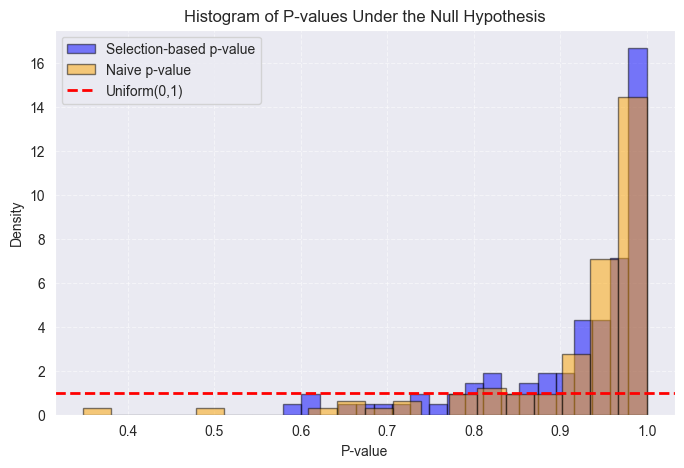

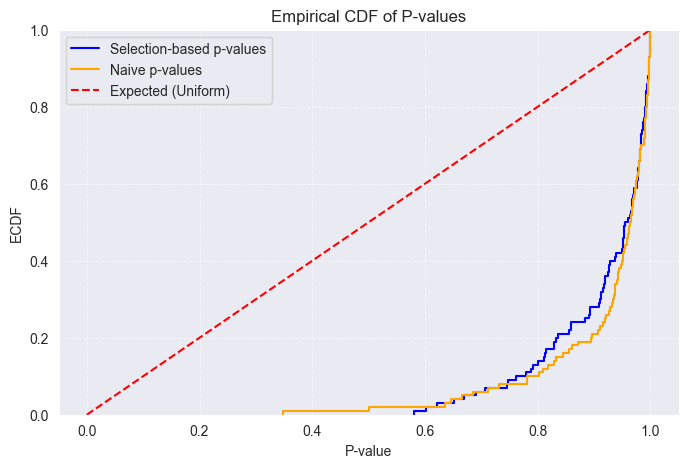

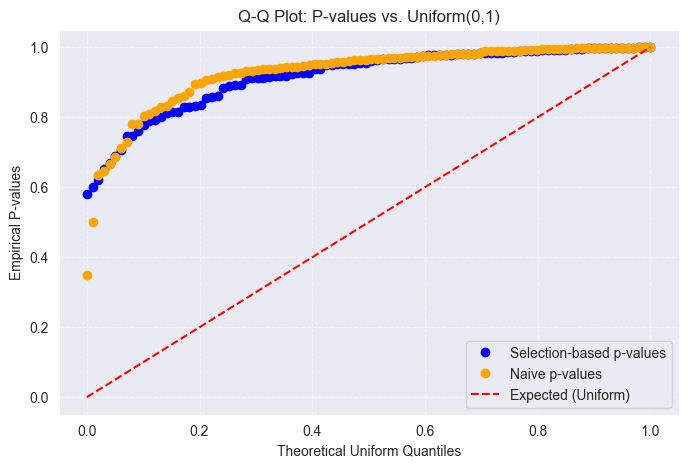

In [28]:
check_p_value_uniformity(n=20,p=15,sigma=1,K=19,tau=1,layer = -1,reduced_prop=0.1,num_trials=100)

level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  1

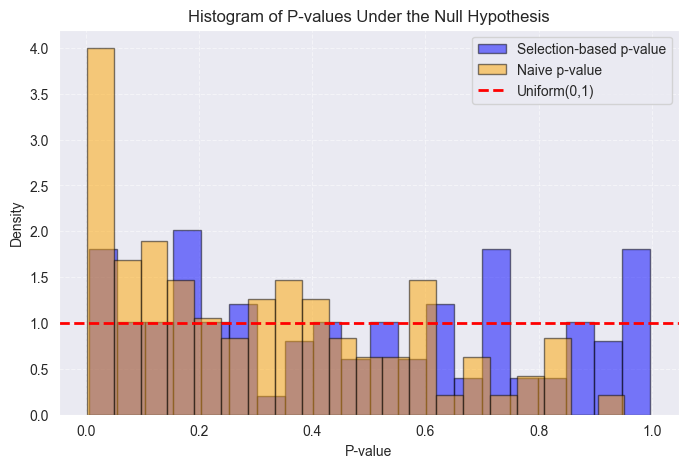

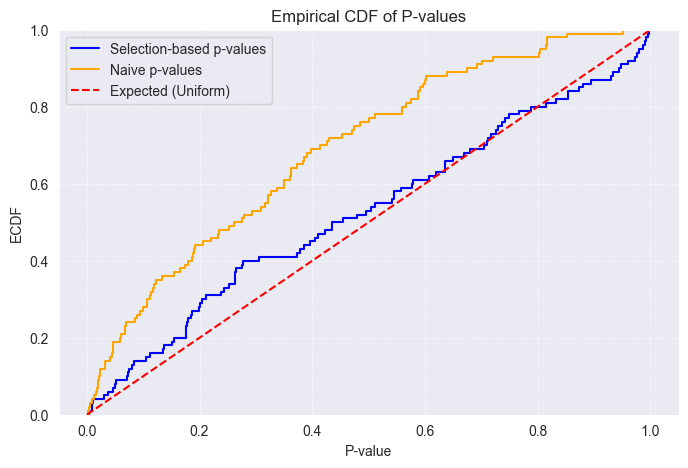

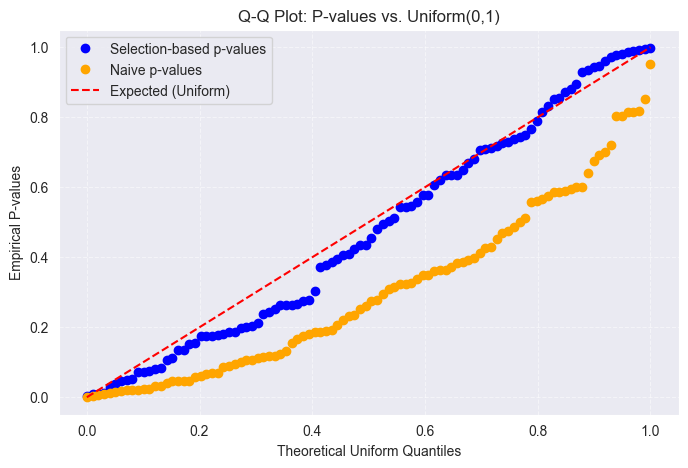

In [17]:
# ncoarse = 200
check_p_value_uniformity(n=20,p=15,sigma=1,K=5,tau=1,layer = -1,reduced_prop=0.05,num_trials=100)

level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  1

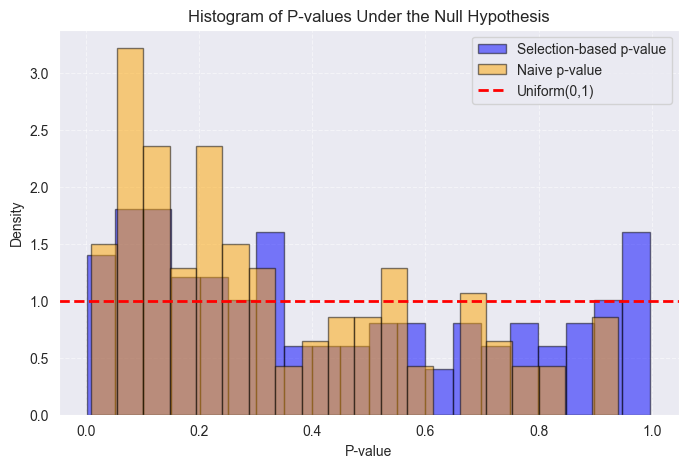

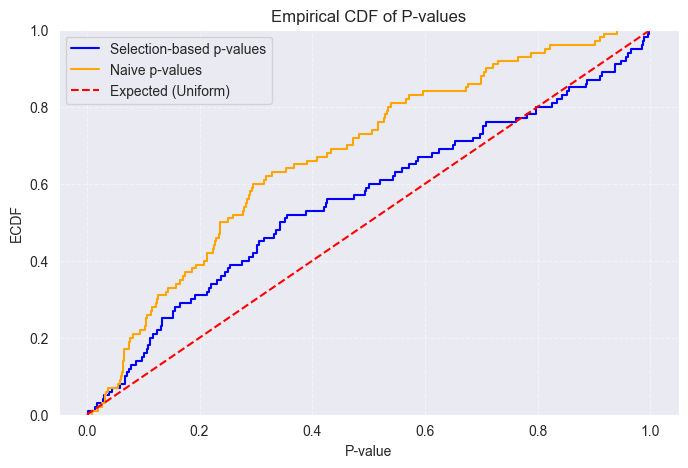

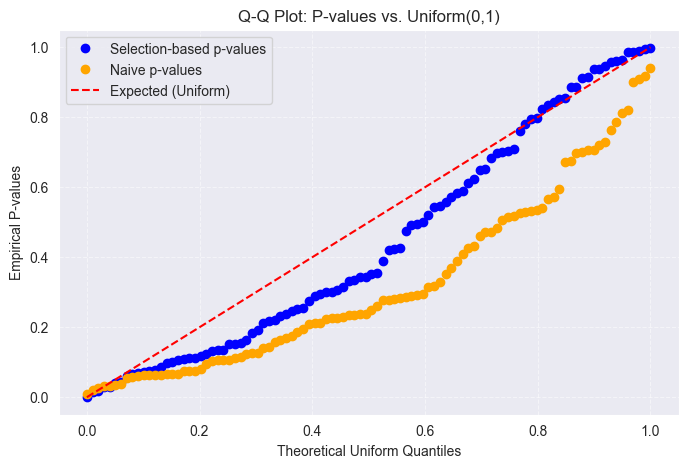

In [43]:
#ncoarse = 400
check_p_value_uniformity(n=20,p=15,sigma=1,K=5,tau=1,layer = -1,reduced_prop=0.3,num_trials=100)

level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  1

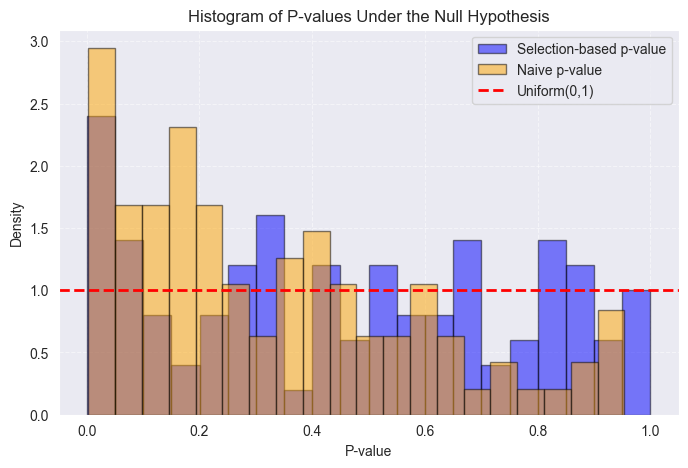

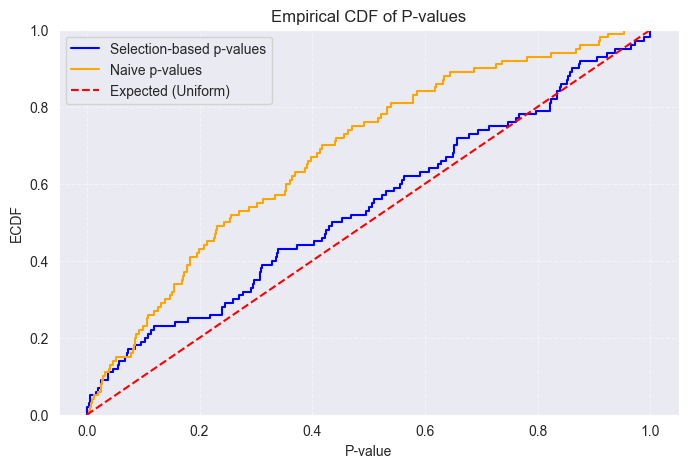

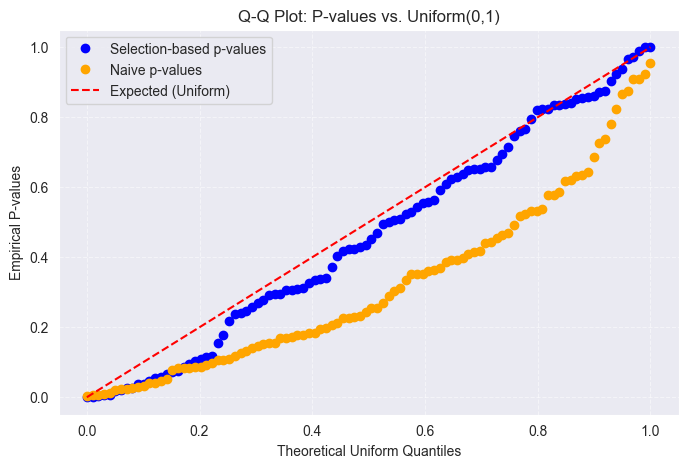

In [58]:
#ncoarse = 200
check_p_value_uniformity(n=20,p=15,sigma=1,K=5,tau=1,layer = -1,reduced_prop=0.2,num_trials=100)

level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2


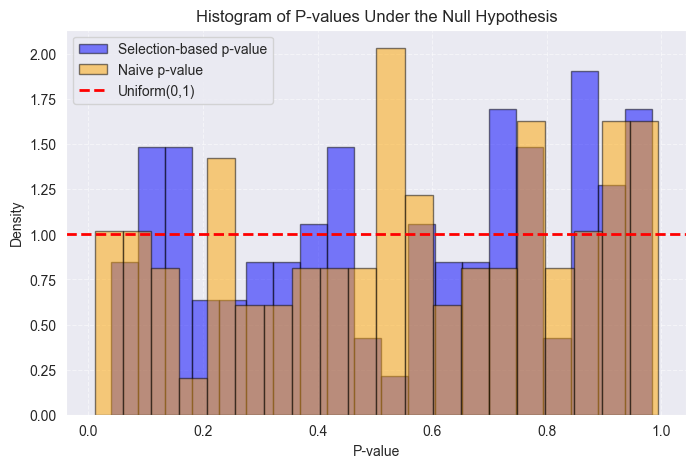

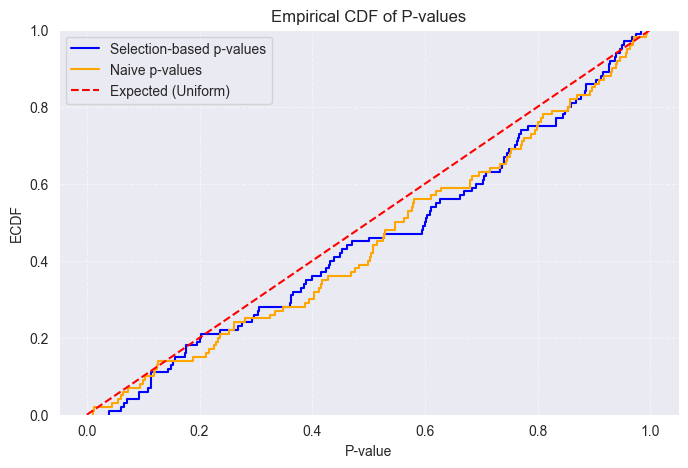

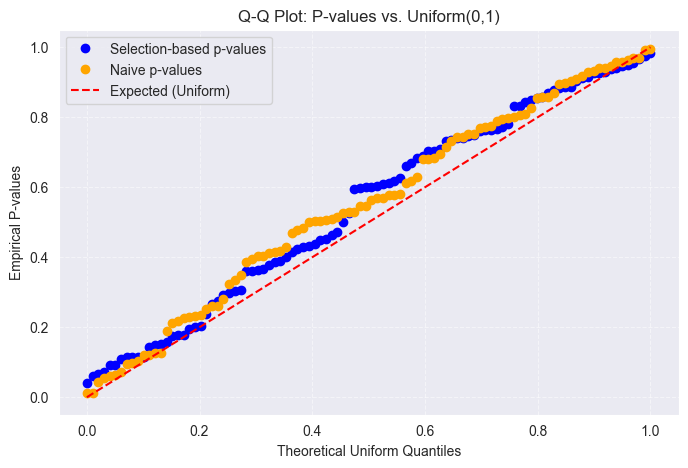

In [54]:
#ncoarse = 600
check_p_value_uniformity(n=20,p=15,sigma=1,K=10,tau=1,layer = -1,reduced_prop=0.8,num_trials=100)

level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2


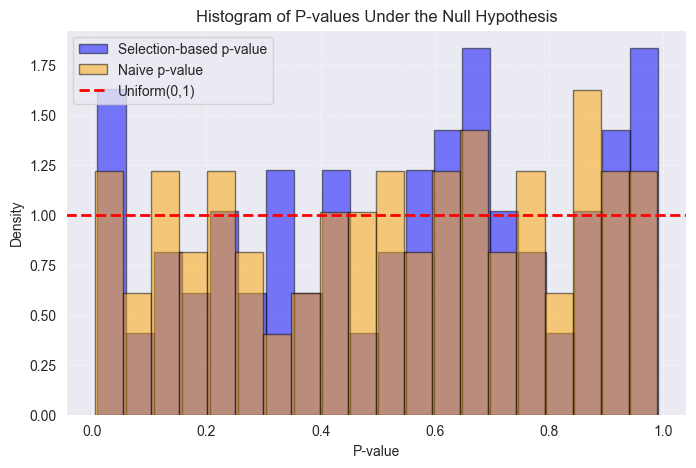

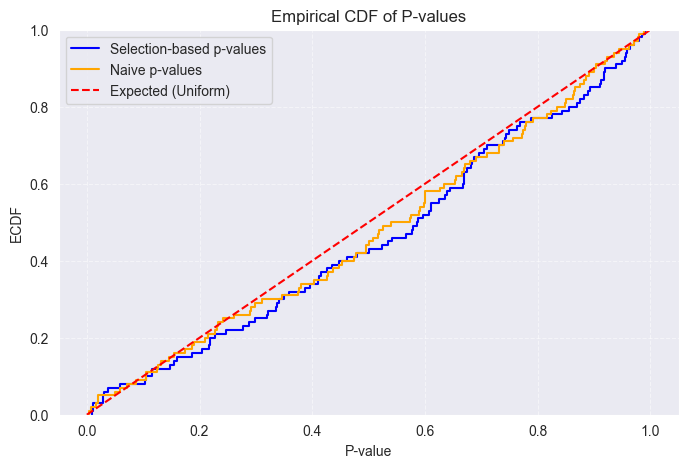

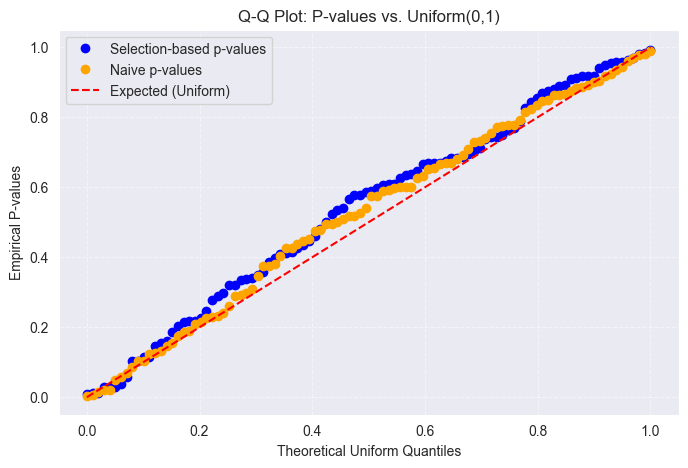

In [57]:
#ncoarse = 600
check_p_value_uniformity(n=20,p=15,sigma=1,K=10,tau=1,layer = -1,reduced_prop=0.01,num_trials=100)

level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  1

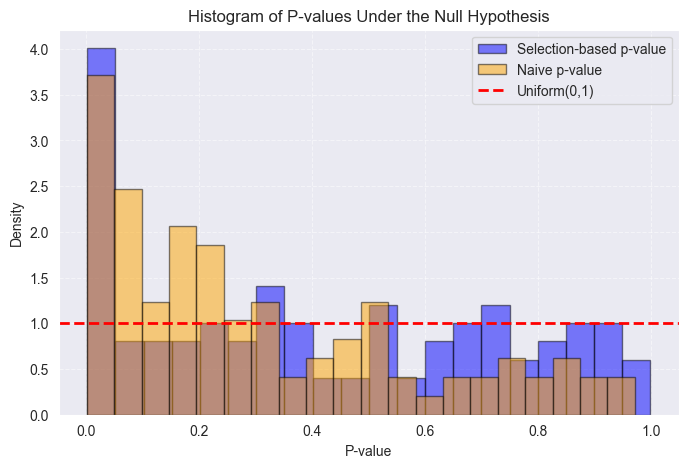

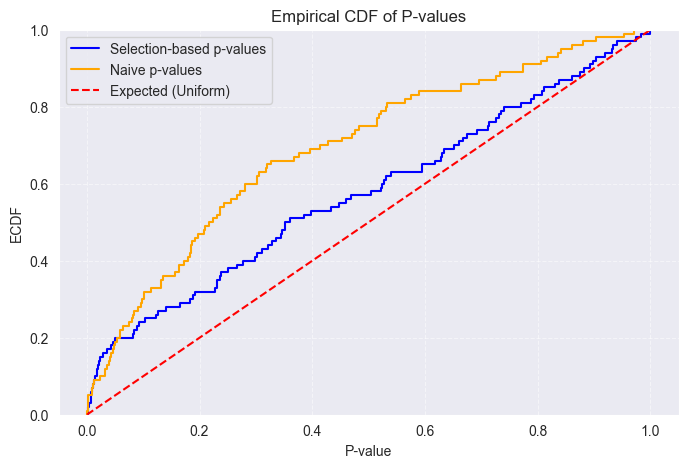

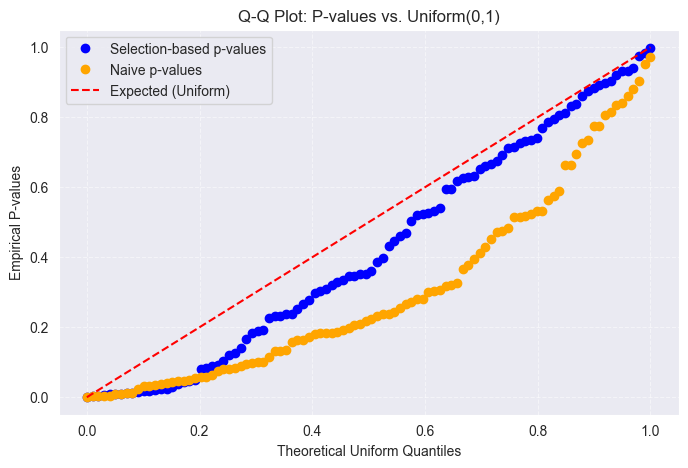

In [36]:
check_p_value_uniformity(n=20,p=15,sigma=1,K=5,tau=1,layer = -1,reduced_prop=0.01,num_trials=100)

level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
le

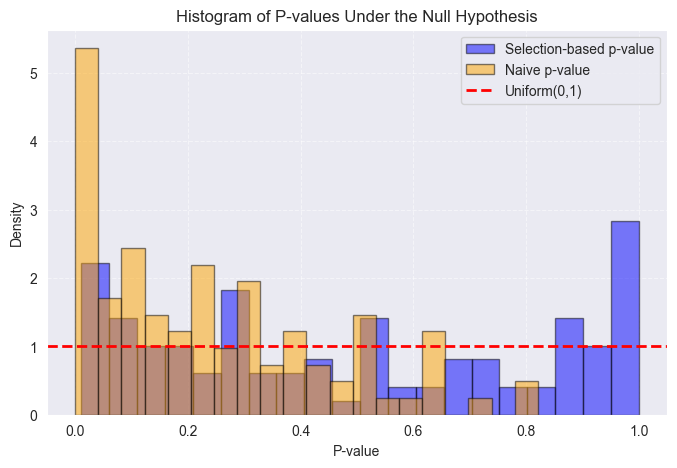

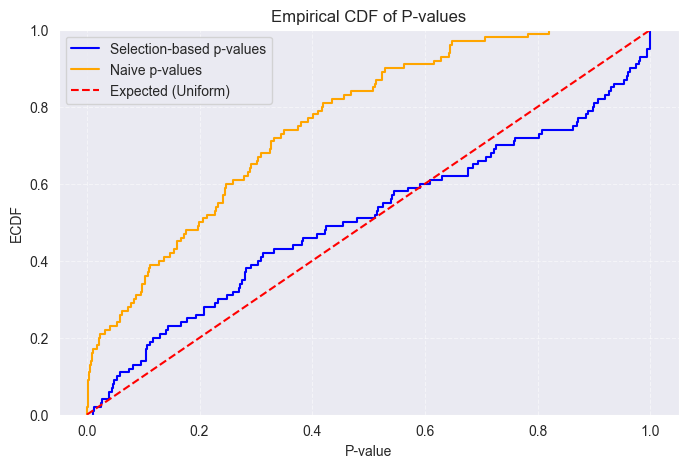

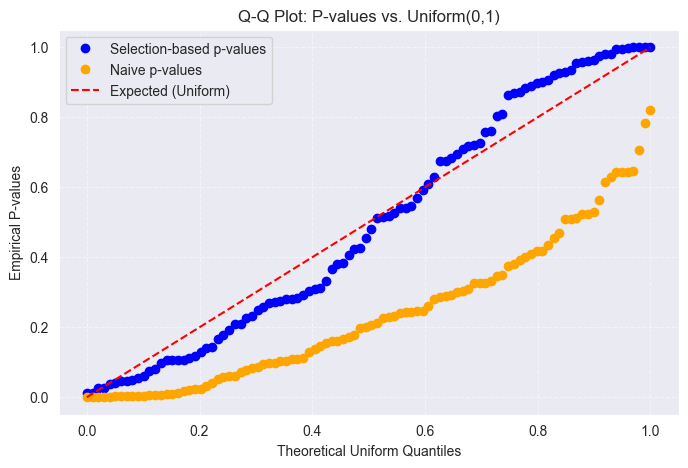

In [20]:
check_p_value_uniformity(n=20,p=15,sigma=1,K=3,tau=1,layer = -1,reduced_prop=0.2,num_trials=100)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


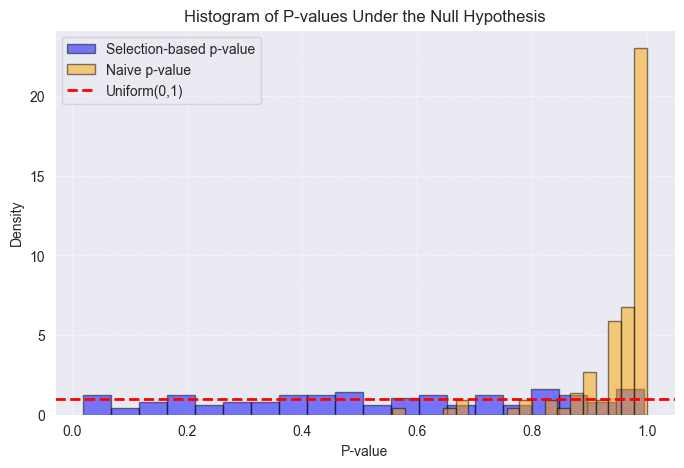

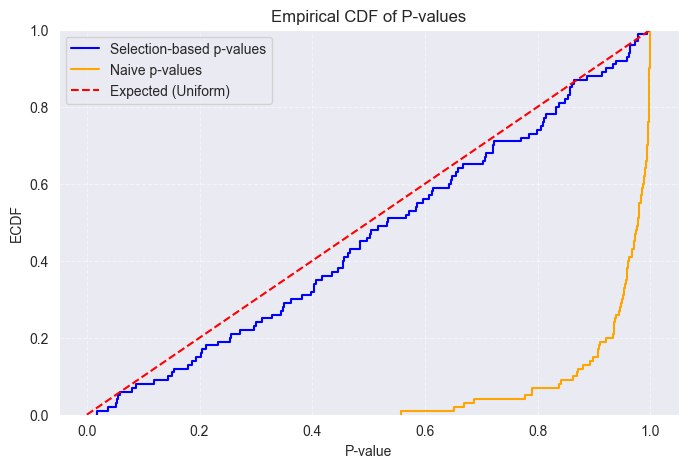

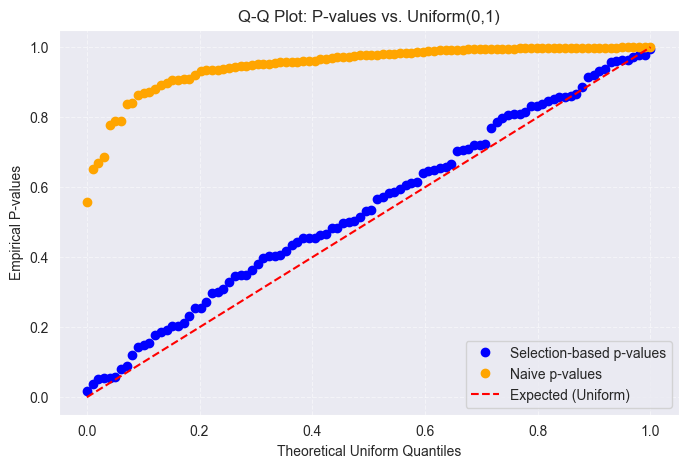

In [5]:
check_p_value_uniformity(n=30,p=15,sigma=1,K=29,tau=1,layer = -1,reduced_prop=0.1,num_trials=100)

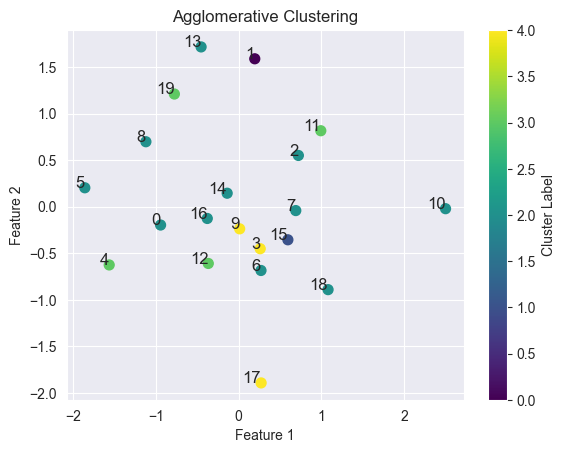

level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1


In [65]:
#X = np.random.uniform(-1, 1, size=(4, 2))
#X, y = make_blobs(n_samples=20, centers=19, cluster_std=1,random_state=42)
n=20
p=15
sigma=1
mu = np.zeros(p)  
X = generate_null_data(n,p,mu,sigma)
# Fit agglomerative clustering
model = AgglomerativeClustering(X, tau=1, n_clusters=5,linkage="single")
model.fit()
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)

# Assign cluster labels from the final cluster nodes
for idx, node in enumerate(model.cluster_nodes):
    for point_index in node.points:
        cluster_labels[point_index] = idx

    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[-1]
node = key[0].parent
pvalue, obs,sel = model.condl_merge_inference(node, grid_width=200,ncoarse=None,ngrid=10000,reduced_prop=0.1)

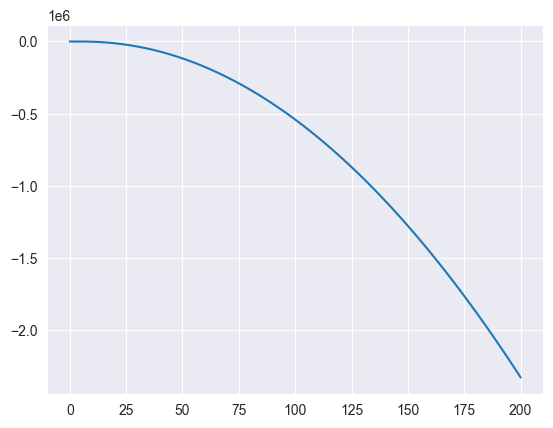

In [66]:
ref_norm = sel
#x = np.linspace(0, 1.5*np.abs(obs_tar), 10000)
y = np.linspace(0.00001,200,num=10000)
plt.plot(y, ref_norm)
plt.show()
plt.show()

In [48]:
def check_p_value_uniformity_by_ncoarse(n, p, sigma, K, tau, layer, ncoarse_list, reduced_prop=0.3, num_trials=100):
    all_p_values = {}
    mu = np.zeros(p)
    p_values_n = []

    for i in range(num_trials):
        X = generate_null_data(n, p, mu, sigma)
        model = AgglomerativeClustering(X, tau=tau, n_clusters=K, linkage="single")
        model.fit()

        winning_nodes = list(model.existing_clusters_log.keys())
        key = winning_nodes[layer]
        node = key[0].parent
        naive_val = naive_p_value(X, node)
        p_values_n.append(naive_val)

        for ncoarse in ncoarse_list:
            p_val, _, _ = model.condl_merge_inference(node, grid_width=20, ncoarse=ncoarse, ngrid=5000, sd=sigma, reduced_prop=reduced_prop)
            if ncoarse not in all_p_values:
                all_p_values[ncoarse] = []
            all_p_values[ncoarse].append(p_val)

    p_values_n = np.array(p_values_n)

    # Histogram
    plt.figure(figsize=(10, 6))
    for ncoarse in ncoarse_list:
        plt.hist(all_p_values[ncoarse], bins=20, density=True, alpha=0.4,
                 label=f"Sel. (ncoarse={ncoarse})", edgecolor='black')
    plt.hist(p_values_n, bins=20, density=True, alpha=0.4,
             label="Naive", edgecolor='gray', linestyle='dashed')
    plt.axhline(1, color='red', linestyle='dashed', linewidth=2, label="Uniform(0,1)")
    plt.xlabel("P-value")
    plt.ylabel("Density")
    plt.title("Histogram of P-values Under the Null")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    # ECDF plot
    plt.figure(figsize=(10, 6))
    for ncoarse in ncoarse_list:
        sns.ecdfplot(all_p_values[ncoarse], label=f"Sel. (ncoarse={ncoarse})")
    sns.ecdfplot(p_values_n, label="Naive", linestyle="--")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("P-value")
    plt.ylabel("ECDF")
    plt.title("ECDF of P-values")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    # Q-Q Plot
    plt.figure(figsize=(10, 6))
    theoretical_quantiles = np.linspace(0, 1, num_trials)
    for ncoarse in ncoarse_list:
        sorted_sel = np.sort(all_p_values[ncoarse])
        plt.plot(theoretical_quantiles, sorted_sel, marker='o', linestyle='',
                 label=f"Sel. (ncoarse={ncoarse})")
    sorted_naive = np.sort(p_values_n)
    plt.plot(theoretical_quantiles, sorted_naive, marker='x', linestyle='',
             label="Naive")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("Theoretical Uniform Quantiles")
    plt.ylabel("Empirical P-values")
    plt.title("Q-Q Plot: P-values vs. Uniform(0,1)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()


level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2


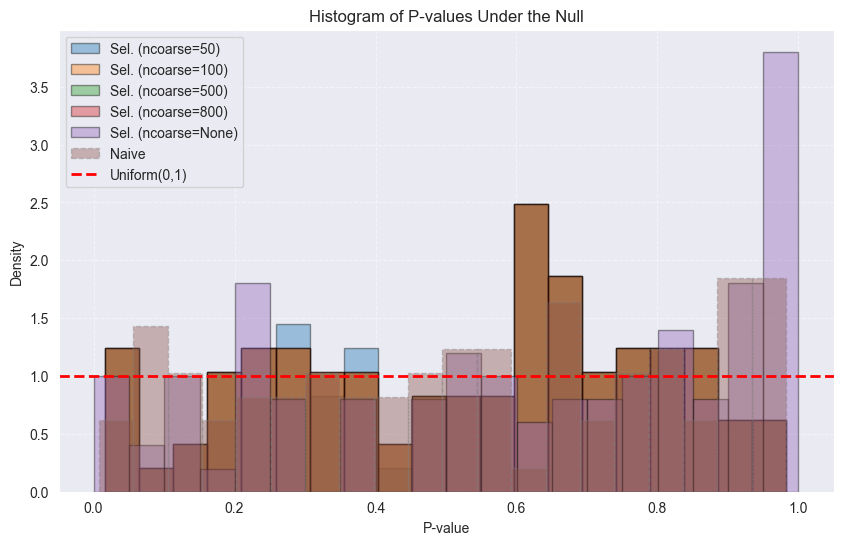

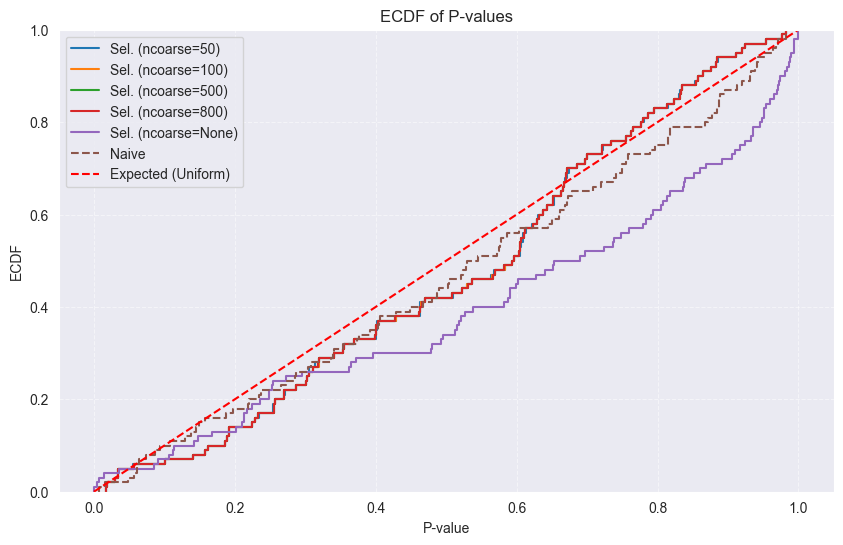

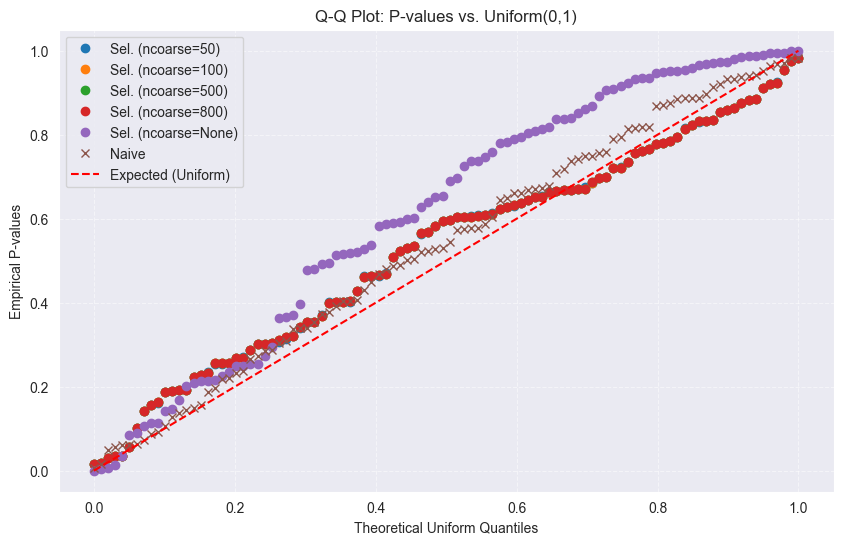

In [49]:
ncoarse_list=[50,100,500,800,None]
check_p_value_uniformity_by_ncoarse(n=20, p=15, sigma=1, K=10, tau=1, layer=-1, ncoarse_list=ncoarse_list, reduced_prop=0.5, num_trials=100)